# specsim vs desisky: Polar Sky Brightness Comparison

This notebook generates side-by-side polar plots comparing:
- **specsim**: Krisciunas & Schaefer (1991) V-band scattered moonlight model
- **desisky**: Broadband brightness predictor (V, g, r, z bands)

For the same moon geometry, we show what specsim can produce (1 panel, V-band only)
versus what desisky predicts (4 panels, V + g + r + z).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import astropy.units as u

import jax
import jax.numpy as jnp

from specsim.atmosphere import krisciunas_schaefer, plot_lunar_brightness
from desisky.io import load_model

## 1. Define a shared moon geometry

We fix the moon position and phase, then evaluate both models across a grid
of telescope pointings.

**Coordinate mapping between specsim and desisky:**
- specsim uses **zenith angles** (0° = overhead, 90° = horizon)
- desisky uses **altitude** (OBSALT = 90° - zenith, MOONALT = 90° - moon_zenith)
- specsim `moon_phase`: 0 = full, 1 = new; illumination = 0.5 * (1 + cos(π * phase))
- desisky `MOONFRAC`: illumination fraction directly (0–1)

In [2]:
# --- Moon geometry (shared between both models) ---
moon_zenith_deg = 45.0      # Moon 45° from zenith
moon_azimuth_deg = 0.0      # Moon due North
moon_phase_ks = 0.25        # specsim convention: 0=full, 1=new

# Derived quantities for desisky
moon_alt_deg = 90.0 - moon_zenith_deg  # MOONALT = 45°
moon_illum_frac = 0.5 * (1 + np.cos(np.pi * moon_phase_ks))  # MOONFRAC

# Fixed desisky-only parameters
transparency_gfa = 0.95     # Clear night
eclipse_frac = 0.0          # No eclipse

print(f"Moon zenith:      {moon_zenith_deg}°")
print(f"Moon altitude:    {moon_alt_deg}°  (= MOONALT for desisky)")
print(f"Moon azimuth:     {moon_azimuth_deg}°")
print(f"Moon phase (KS):  {moon_phase_ks}  (0=full, 1=new)")
print(f"Moon illum frac:  {moon_illum_frac:.3f}  (= MOONFRAC for desisky)")
print(f"Transparency:     {transparency_gfa}")
print(f"Eclipse frac:     {eclipse_frac}")

Moon zenith:      45.0°
Moon altitude:    45.0°  (= MOONALT for desisky)
Moon azimuth:     0.0°
Moon phase (KS):  0.25  (0=full, 1=new)
Moon illum frac:  0.854  (= MOONFRAC for desisky)
Transparency:     0.95
Eclipse frac:     0.0


## 2. Build the observation grid

Same polar grid of telescope pointings for both models.
We compute the separation angle at each grid point (needed by both models).

In [3]:
ngrid = 250

# Observation grid in (zenith, azimuth)
obs_zenith_1d = np.linspace(0.0, 90.0, ngrid, endpoint=False)  # degrees
obs_az_1d = np.linspace(0.0, 360.0, ngrid)                     # degrees

# 2D grids: obs_az varies along axis 0, obs_zenith along axis 1
obs_az_2d, obs_zenith_2d = np.meshgrid(obs_az_1d, obs_zenith_1d, indexing='ij')

# Derived: observation altitude grid
obs_alt_2d = 90.0 - obs_zenith_2d

# Separation angle between moon and each grid point
cos_sep = (
    np.cos(np.radians(moon_zenith_deg)) * np.cos(np.radians(obs_zenith_2d))
    + np.cos(np.radians(moon_azimuth_deg - obs_az_2d))
    * np.sin(np.radians(moon_zenith_deg))
    * np.sin(np.radians(obs_zenith_2d))
)
cos_sep = np.clip(cos_sep, -1, 1)
sep_deg = np.degrees(np.arccos(cos_sep))

# Polar plot coordinates (for matplotlib)
theta_2d = np.radians(obs_az_2d)   # azimuth in radians
r_2d = obs_zenith_2d                # zenith angle as radial coordinate

# --- Extrapolation mask ---
# The broadband model was trained with:
#   MOONSEP in [31.51°, 89.97°]  (median 54.9°)
#   OBSALT  in [30.85°, 89.77°]  (median 61.7°)
# We mask BOTH the upper AND lower bounds because ReLU MLPs extrapolate badly
# in either direction. The earlier version only masked MOONSEP > 90° which
# left the MOONSEP < 31° region (right around the moon) as extrapolation,
# causing ringing artifacts and weird z-band behavior.
MOONSEP_MIN, MOONSEP_MAX = 31.0, 90.0
OBSALT_MIN, OBSALT_MAX = 31.0, 90.0
valid_mask = (
    (sep_deg >= MOONSEP_MIN) & (sep_deg <= MOONSEP_MAX)
    & (obs_alt_2d >= OBSALT_MIN) & (obs_alt_2d <= OBSALT_MAX)
)

print(f"Grid shape: {obs_zenith_2d.shape}")
print(f"Separation angle range on grid: {sep_deg.min():.1f} - {sep_deg.max():.1f} deg")
print(f"Valid points (within training envelope): "
      f"{valid_mask.sum()} / {valid_mask.size} ({100 * valid_mask.mean():.0f}%)")

Grid shape: (250, 250)
Separation angle range on grid: 0.0 - 134.6 deg
Valid points (within training envelope): 31864 / 62500 (51%)


### 2a. Diagnostic: visualize where the broadband model is trained

Shows the valid (training-envelope) region overlaid on the polar plot. Useful
for understanding what the mask covers for any given moon geometry.

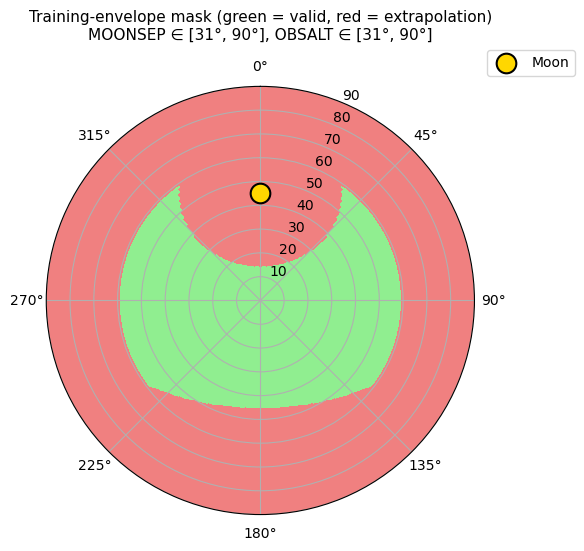

Excluded for MOONSEP < 31.0°: 14% of grid (ring around the moon — extrapolation)
Excluded for OBSALT  < 31.0°: 34% of grid (outer ring near horizon — DESI doesn't point here)


In [4]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(0., 90.)

# Show the valid region in one color, invalid in another
diag = np.where(valid_mask, 1.0, 0.0)
ax.contourf(theta_2d, r_2d, diag, levels=[-0.5, 0.5, 1.5],
            colors=['lightcoral', 'lightgreen'])

# Mark the moon
ax.scatter(np.radians(moon_azimuth_deg), moon_zenith_deg,
           s=200, marker='o', color='gold', edgecolor='k', lw=1.5,
           label='Moon', zorder=5)

ax.set_title(
    f'Training-envelope mask (green = valid, red = extrapolation)\n'
    f'MOONSEP ∈ [{MOONSEP_MIN:.0f}°, {MOONSEP_MAX:.0f}°], '
    f'OBSALT ∈ [{OBSALT_MIN:.0f}°, {OBSALT_MAX:.0f}°]',
    fontsize=11, pad=15,
)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

# Quick summary of what's being excluded and why
excl_moonsep = (sep_deg < MOONSEP_MIN).sum() / sep_deg.size
excl_obsalt = (obs_alt_2d < OBSALT_MIN).sum() / obs_alt_2d.size
print(f"Excluded for MOONSEP < {MOONSEP_MIN}°: {100*excl_moonsep:.0f}% of grid "
      f"(ring around the moon — extrapolation)")
print(f"Excluded for OBSALT  < {OBSALT_MIN}°: {100*excl_obsalt:.0f}% of grid "
      f"(outer ring near horizon — DESI doesn't point here)")

## 3. specsim: Krisciunas & Schaefer V-band prediction

### 3a. Compute V-band dark-sky floor from DESI data

For an apples-to-apples comparison with desisky, we need to add a dark-sky floor
to specsim's KS91 output. KS91 only predicts scattered moonlight, while desisky
predicts **total** sky brightness (moonlight + airglow + zodiacal + continuum).

We compute the floor from the median of near-zenith dark-time spectra in the
DESI VAC file, so it's self-consistent with desisky's training data. The floor
is then airmass-extincted across the polar grid (matching specsim's
`extinct_emission=True` behavior) before being flux-added to the KS91 moonlight.

In [5]:
import speclite.filters
from astropy.io import fits

VAC_PATH = '/home/mdowicz/.desisky/data/dr1/sky_spectra_vac_v1.fits'

with fits.open(VAC_PATH) as hdul:
    vac_wave = hdul['WAVELENGTH'].data
    vac_flux = hdul['FLUX'].data
    vac_meta = hdul['METADATA'].data

# Near-zenith dark-time mask (airmass ~1.05 for OBSALT > 70°, close to zenith)
near_zenith_dark = (
    (vac_meta['SUNALT'] < -20)
    & (vac_meta['MOONALT'] < -5)
    & (vac_meta['OBSALT'] > 70)
)
print(f"Near-zenith dark spectra used: {near_zenith_dark.sum()}")

# Median dark-time spectrum
dark_median_spec = np.median(vac_flux[near_zenith_dark], axis=0)

# Compute V-band surface brightness via bessell-V filter.
# speclite expects flux density per cm^2 (not per arcsec^2), so we strip the
# arcsec^2 from the units and interpret the resulting AB magnitude as a
# surface brightness magnitude (mag/arcsec^2). This matches specsim's own
# convention for sky surface brightness (see specsim.atmosphere.Moon).
flux_unit_no_arcsec = 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)

vband_filter = speclite.filters.load_filter('bessell-V')
dark_V_zenith = vband_filter.get_ab_magnitude(
    dark_median_spec * flux_unit_no_arcsec,
    vac_wave * u.Angstrom,
)
print(f"Dark sky V-band (zenith reference): {dark_V_zenith:.3f} mag/arcsec²")

Near-zenith dark spectra used: 1033
Dark sky V-band (zenith reference): 21.631 mag/arcsec²


In [6]:
vband_extinction = 0.162  # specsim default for Kitt Peak

# --- KS91 scattered moonlight V-band ---
# KS91 is already airmass-aware (see obs_zenith term in the formula).
ks_moon_V = krisciunas_schaefer(
    obs_zenith_2d * u.deg,
    moon_zenith_deg * u.deg,
    sep_deg * u.deg,
    moon_phase_ks,
    vband_extinction,
).value  # mag/arcsec²

# --- Airmass-extincted dark floor ---
# specsim's formula for airmass (same as krisciunas_schaefer internally):
airmass_2d = 1.0 / np.sqrt(1.0 - 0.96 * np.sin(np.radians(obs_zenith_2d))**2)

# The dark floor is extincted relative to its zenith value. At airmass=1 we
# recover dark_V_zenith; at higher airmass the dark emission is dimmer.
# This matches specsim's Atmosphere.surface_brightness with extinct_emission=True.
dark_V_pointing = dark_V_zenith + vband_extinction * (airmass_2d - 1.0)

# --- Flux-add moonlight + dark floor to get total specsim V ---
# Magnitudes don't add linearly; we work in flux space:
flux_moon = 10.0 ** (-0.4 * ks_moon_V)
flux_dark = 10.0 ** (-0.4 * dark_V_pointing)
flux_total = flux_moon + flux_dark
specsim_total_V = -2.5 * np.log10(flux_total)  # mag/arcsec²

print(f"KS91 moonlight V range:       {ks_moon_V.min():.2f} - {ks_moon_V.max():.2f} mag/arcsec²")
print(f"Dark floor range (extincted): {dark_V_pointing.min():.2f} - {dark_V_pointing.max():.2f} mag/arcsec²")
print(f"specsim total V range:        {specsim_total_V.min():.2f} - {specsim_total_V.max():.2f} mag/arcsec²")

KS91 moonlight V range:       17.72 - 19.99 mag/arcsec²
Dark floor range (extincted): 21.63 - 22.28 mag/arcsec²
specsim total V range:        17.69 - 19.78 mag/arcsec²


### 3b. Standalone specsim polar plot (for slide A of the presentation)

Calls specsim's own `plot_lunar_brightness` function — no desisky, no dark
floor, just the pure KS91 V-band scattered moonlight model. This is the
"what specsim does today" figure for the first slide of the two-slide
comparison, and it's the exact visualization David pointed to during the
meeting.

Saves as `slide_a_specsim_only.png`.

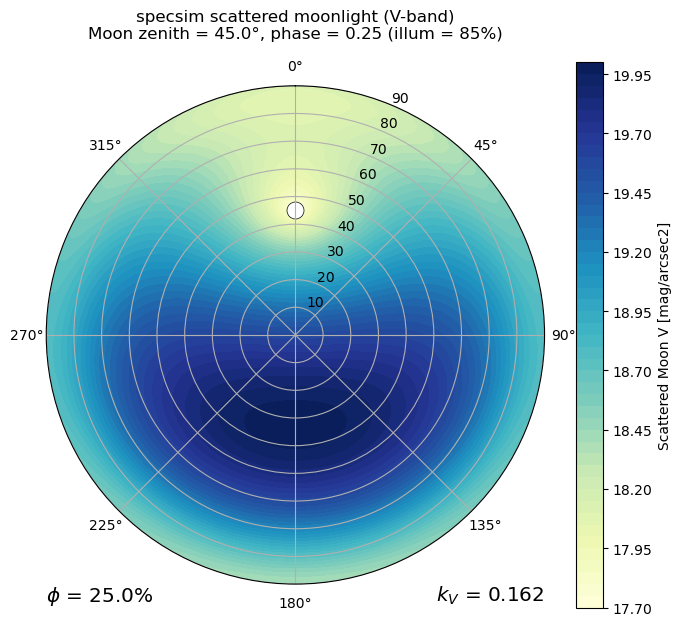

In [7]:
# Standalone specsim polar plot for slide A of the presentation.
# Uses specsim's own plot_lunar_brightness function, which visualizes pure
# KS91 scattered moonlight (V-band only, no dark floor). This is what
# specsim ships with — the cleanest "what specsim does today" visual and
# exactly the function David pointed to during the meeting.

fig_specsim, ax_specsim, cax_specsim = plot_lunar_brightness(
    moon_zenith=moon_zenith_deg * u.deg,
    moon_azimuth=moon_azimuth_deg * u.deg,
    moon_phase=moon_phase_ks,
    vband_extinction=vband_extinction,
    ngrid=250,
    cmap='YlGnBu',
    figure_size=(7, 6),
)

ax_specsim.set_title(
    f'specsim scattered moonlight (V-band)\n'
    f'Moon zenith = {moon_zenith_deg}°, phase = {moon_phase_ks} '
    f'(illum = {moon_illum_frac:.0%})',
    fontsize=12, pad=15,
)

plt.savefig('slide_a_specsim_only.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. desisky: Broadband brightness prediction (V, g, r, z)

In [8]:
# Load the pre-trained broadband model
model, meta = load_model("broadband")
print(f"Model architecture: {meta}")

Model architecture: {'schema': 0, 'arch': {'depth': 5, 'in_size': 6, 'out_size': 4, 'width_size': 128}}


In [9]:
# Build the desisky input array for every grid point
# Feature order: [MOONSEP, OBSALT, MOONALT, MOONFRAC, TRANSPARENCY_GFA, ECLIPSE_FRAC]
n_points = obs_zenith_2d.size

inputs = np.column_stack([
    sep_deg.ravel(),                                   # MOONSEP
    obs_alt_2d.ravel(),                                # OBSALT
    np.full(n_points, moon_alt_deg),                   # MOONALT (fixed)
    np.full(n_points, moon_illum_frac),                # MOONFRAC (fixed)
    np.full(n_points, transparency_gfa),               # TRANSPARENCY_GFA (fixed)
    np.full(n_points, eclipse_frac),                   # ECLIPSE_FRAC (fixed)
]).astype(np.float32)

print(f"Input shape: {inputs.shape}  (n_points × 6 features)")
print(f"Sample input row: {inputs[0]}")

Input shape: (62500, 6)  (n_points × 6 features)
Sample input row: [45.        90.        45.         0.8535534  0.95       0.       ]


In [10]:
# Run batch inference with vmap
preds = jax.vmap(model)(jnp.array(inputs))  # shape (n_points, 4)
preds_np = np.array(preds)

# Reshape back to grid
band_names = ["V", "g", "r", "z"]
desisky_bands = {}
for i, name in enumerate(band_names):
    desisky_bands[name] = preds_np[:, i].reshape(obs_zenith_2d.shape)

for name in band_names:
    vals = desisky_bands[name]
    print(f"desisky {name}-band range: {np.nanmin(vals):.1f} – {np.nanmax(vals):.1f} mag/arcsec²")

desisky V-band range: 17.8 – 19.8 mag/arcsec²
desisky g-band range: 17.6 – 19.8 mag/arcsec²
desisky r-band range: 17.9 – 19.9 mag/arcsec²
desisky z-band range: 17.9 – 20.9 mag/arcsec²


## 5. Side-by-side comparison: specsim (1 panel) vs desisky (4 panels)

Left: specsim's KS91 V-band only.  
Right 2×2: desisky V, g, r, z predictions for the same geometry.

In [11]:
def make_polar_ax(ax, data, title, cmap, vmin, vmax, moon_az_rad, moon_zen_deg,
                  mask=None, nlevels=50):
    """Draw a polar contour plot on an existing axes.

    If mask is provided, pixels where mask is False are set to NaN (not plotted).

    IMPORTANT: we pass explicit `levels` to contourf rather than a level count,
    so the resulting mappable honors the requested vmin/vmax exactly. Without
    this, contourf computes levels from the actual data range, which means
    panels with different data ranges produce colorbars showing different
    ranges — even when you pass the same vmin/vmax. This matters when several
    panels are supposed to share a single colorbar (e.g., a row colorbar in
    the multi-phase plot) or cross-band comparisons in the main figure.
    """
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_ylim(0., 90.)

    plot_data = data.copy()
    if mask is not None:
        plot_data = plot_data.astype(float)
        plot_data[~mask] = np.nan

    # Explicit levels anchored to vmin/vmax → all panels share the same
    # color mapping when called with the same vmin/vmax.
    levels = np.linspace(vmin, vmax, nlevels + 1)
    cax = ax.contourf(theta_2d, r_2d, plot_data, levels=levels,
                      cmap=cmap, vmin=vmin, vmax=vmax, extend='both')
    ax.scatter(moon_az_rad, moon_zen_deg, s=120, marker='o',
               color='w', lw=0.8, edgecolor='k', zorder=5)
    ax.set_title(title, fontsize=13, pad=12)
    return cax

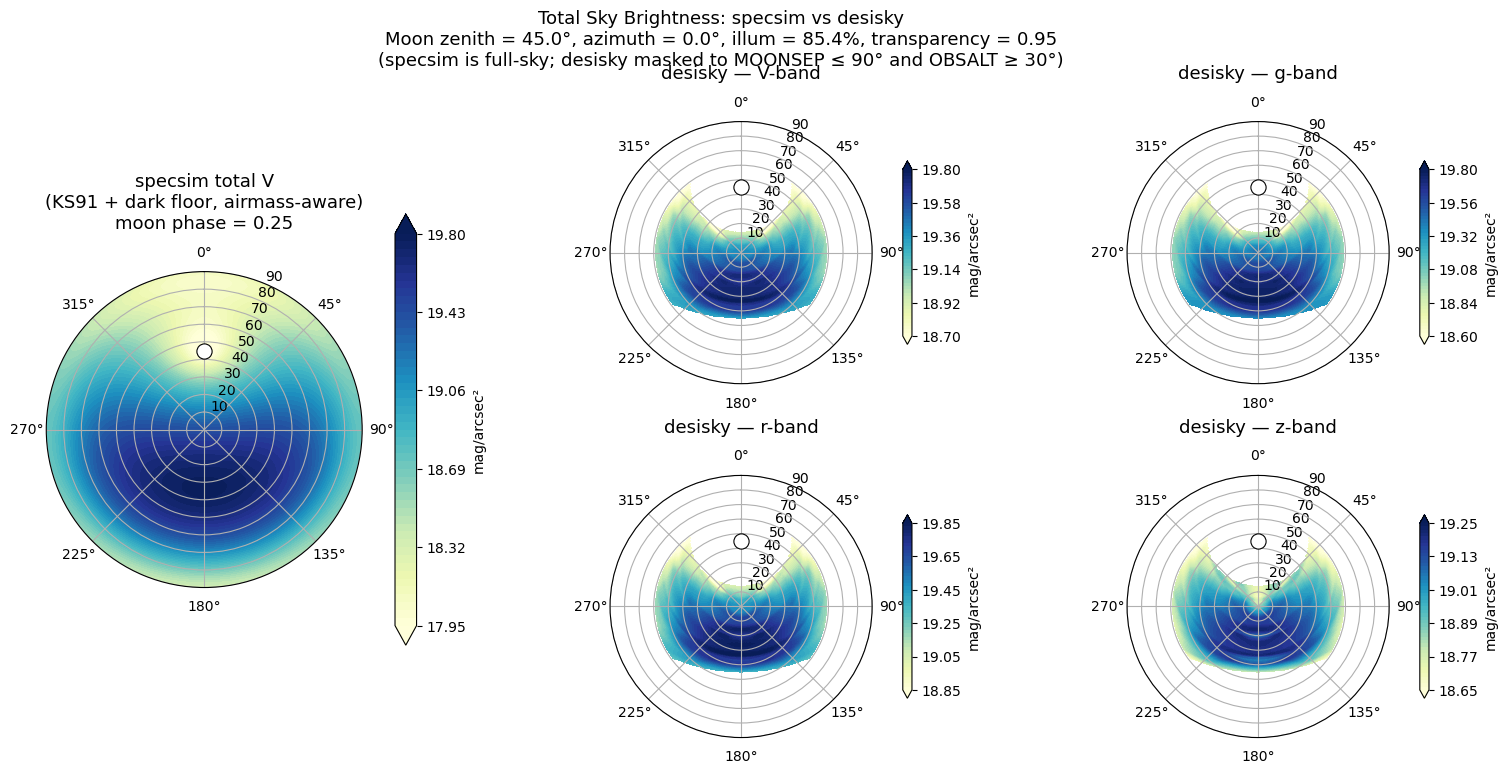

In [12]:
moon_az_rad = np.radians(moon_azimuth_deg)

# Mask desisky predictions to only show the valid (non-extrapolating) region
desisky_masked = {}
for band in band_names:
    arr = desisky_bands[band].copy().astype(float)
    arr[~valid_mask] = np.nan
    desisky_masked[band] = arr

def _round_vrange(vmin, vmax, step=0.05):
    """Snap colorbar limits to a grid of ``step`` mag/arcsec² so tick labels
    come out as clean values like 19.70 instead of the 4-decimal outputs of
    np.percentile. Floor vmin / ceil vmax so the rounded window always
    contains the original range."""
    import math
    return math.floor(vmin / step) * step, math.ceil(vmax / step) * step

# Color range for specsim V: use the full-sky specsim_total_V range, rounded
# to clean values for the colorbar.
spec_finite = specsim_total_V[np.isfinite(specsim_total_V)]
vmin_spec, vmax_spec = _round_vrange(
    np.percentile(spec_finite, 1), np.percentile(spec_finite, 99),
)

fig = plt.figure(figsize=(18, 8))
cmap = 'YlGnBu'

# Left: specsim total V (KS91 moonlight + airmass-extincted dark floor)
ax_spec = fig.add_subplot(1, 3, 1, projection='polar')
cax_spec = make_polar_ax(
    ax_spec, specsim_total_V,
    f'specsim total V\n(KS91 + dark floor, airmass-aware)\nmoon phase = {moon_phase_ks}',
    cmap, vmin_spec, vmax_spec, moon_az_rad, moon_zenith_deg,
)
cb_spec = fig.colorbar(cax_spec, ax=ax_spec, pad=0.08, shrink=0.7, label='mag/arcsec²')
cb_spec.set_ticks(np.round(np.linspace(vmin_spec, vmax_spec, 6), 2))

# Right: desisky 2x2 grid (masked to valid region only)
gs = fig.add_gridspec(2, 2, left=0.42, right=0.92, hspace=0.35, wspace=0.35)
for idx, band in enumerate(band_names):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col], projection='polar')

    band_finite = desisky_masked[band][np.isfinite(desisky_masked[band])]
    vmin_b, vmax_b = _round_vrange(
        np.percentile(band_finite, 1), np.percentile(band_finite, 99),
    )

    cax_ds = make_polar_ax(
        ax, desisky_bands[band],
        f'desisky — {band}-band',
        cmap, vmin_b, vmax_b, moon_az_rad, moon_zenith_deg,
        mask=valid_mask,
    )
    cb_ds = fig.colorbar(cax_ds, ax=ax, pad=0.08, shrink=0.7, label='mag/arcsec²')
    cb_ds.set_ticks(np.round(np.linspace(vmin_b, vmax_b, 6), 2))

fig.suptitle(
    f'Total Sky Brightness: specsim vs desisky\n'
    f'Moon zenith = {moon_zenith_deg}°, azimuth = {moon_azimuth_deg}°, '
    f'illum = {moon_illum_frac:.1%}, transparency = {transparency_gfa}\n'
    f'(specsim is full-sky; desisky masked to MOONSEP ≤ 90° and OBSALT ≥ 30°)',
    fontsize=13, y=1.02,
)

plt.savefig('polar_specsim_vs_desisky.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Direct V-band comparison: specsim vs desisky

Residual map showing the difference between the two V-band predictions.

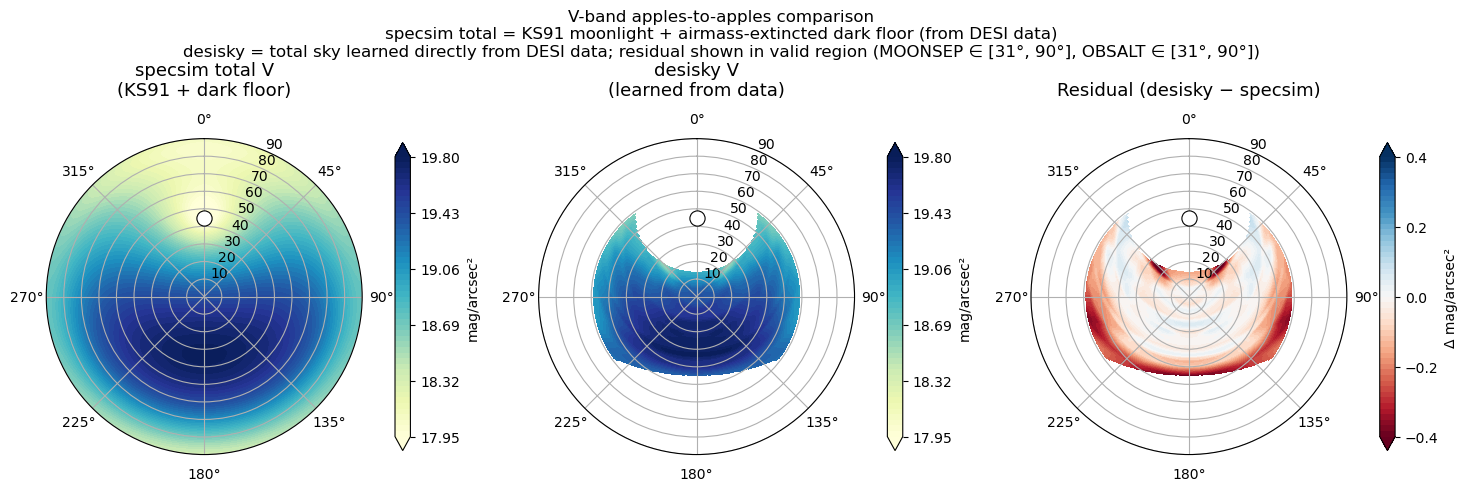


V-band residual (desisky - specsim total) in valid region:
  Mean:   -0.066 mag/arcsec²
  Median: -0.033 mag/arcsec²
  Std:    0.093 mag/arcsec²
  95% of pixels within: [-0.33, +0.04] mag/arcsec²


In [13]:
# Apples-to-apples V-band comparison: both sides are "total sky brightness"
residual = desisky_bands['V'] - specsim_total_V

# Use specsim's FULL-sky range for the color scale (percentile 1-99 across the
# entire grid, not just the valid region). This avoids the earlier plotting
# artifact where pixels outside the mask saturated because the color range was
# calibrated only to valid-region values. desisky uses the same range for
# direct visual comparison.
spec_full_finite = specsim_total_V[np.isfinite(specsim_total_V)]
vmin_v, vmax_v = _round_vrange(
    np.percentile(spec_full_finite, 1),
    np.percentile(spec_full_finite, 99),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                          subplot_kw=dict(projection='polar'))

# specsim total V (full sky, analytic + static dark template)
cax0 = make_polar_ax(axes[0], specsim_total_V, 'specsim total V\n(KS91 + dark floor)',
                      'YlGnBu', vmin_v, vmax_v,
                      moon_az_rad, moon_zenith_deg)
cb0 = fig.colorbar(cax0, ax=axes[0], pad=0.08, shrink=0.8, label='mag/arcsec²')
cb0.set_ticks(np.round(np.linspace(vmin_v, vmax_v, 6), 2))

# desisky V-band (masked to valid region, same color range as specsim)
cax1 = make_polar_ax(axes[1], desisky_bands['V'], 'desisky V\n(learned from data)',
                      'YlGnBu', vmin_v, vmax_v,
                      moon_az_rad, moon_zenith_deg,
                      mask=valid_mask)
cb1 = fig.colorbar(cax1, ax=axes[1], pad=0.08, shrink=0.8, label='mag/arcsec²')
cb1.set_ticks(np.round(np.linspace(vmin_v, vmax_v, 6), 2))

# Residual (desisky - specsim), masked to valid region. Round to a 0.1-mag
# grid so the diverging colorbar ticks read cleanly.
res_valid = residual[valid_mask]
import math
res_abs_max = math.ceil(np.nanpercentile(np.abs(res_valid), 99) / 0.1) * 0.1
cax2 = make_polar_ax(axes[2], residual, 'Residual (desisky − specsim)',
                      'RdBu', -res_abs_max, res_abs_max,
                      moon_az_rad, moon_zenith_deg,
                      mask=valid_mask)
cb2 = fig.colorbar(cax2, ax=axes[2], pad=0.08, shrink=0.8, label='Δ mag/arcsec²')
cb2.set_ticks(np.round(np.linspace(-res_abs_max, res_abs_max, 5), 2))

fig.suptitle(
    'V-band apples-to-apples comparison\n'
    'specsim total = KS91 moonlight + airmass-extincted dark floor (from DESI data)\n'
    'desisky = total sky learned directly from DESI data; '
    'residual shown in valid region (MOONSEP ∈ [31°, 90°], OBSALT ∈ [31°, 90°])',
    fontsize=12, y=1.07,
)
plt.savefig('polar_vband_residual.png', dpi=200, bbox_inches='tight')
plt.show()

# Print summary stats for the valid region
print(f"\nV-band residual (desisky - specsim total) in valid region:")
print(f"  Mean:   {np.mean(res_valid):+.3f} mag/arcsec²")
print(f"  Median: {np.median(res_valid):+.3f} mag/arcsec²")
print(f"  Std:    {np.std(res_valid):.3f} mag/arcsec²")
print(f"  95% of pixels within: [{np.percentile(res_valid, 2.5):+.2f}, {np.percentile(res_valid, 97.5):+.2f}] mag/arcsec²")

## 7. Multiple moon phases

Show how predictions vary across moon phases. Each row is a different moon
phase; left panel is specsim total V, right four are desisky V/g/r/z.

### Reference: KS phase → MOONFRAC illumination

specsim's `moon_phase` and desisky's `MOONFRAC` use different conventions:

- **specsim KS phase**: 0 = full moon, 1 = new moon
- **desisky MOONFRAC**: illumination fraction (0 = new, 1 = full)
- Conversion: `illumination = 0.5 * (1 + cos(π · KS_phase))`
- Training filter: `MOONFRAC > 0.5` (moon-contaminated subset)

| KS phase | MOONFRAC (illumination) | Common name     | In training? |
|----------|--------------------------|-----------------|--------------|
| 0.00     | 1.000                    | full            | ✓            |
| 0.10     | 0.975                    | near-full       | ✓            |
| 0.20     | 0.905                    | waxing/waning gibbous | ✓      |
| 0.25     | 0.854                    | gibbous         | ✓            |
| 0.30     | 0.794                    | gibbous         | ✓            |
| 0.40     | 0.655                    | gibbous         | ✓            |
| **0.50** | **0.500**                | **first/last quarter** | **✗ boundary** |
| 0.60     | 0.345                    | crescent        | ✗            |
| 0.75     | 0.146                    | crescent        | ✗            |
| 1.00     | 0.000                    | new             | ✗            |

The three phases shown below (`[0.1, 0.25, 0.4]`) correspond to illuminations
`[0.975, 0.854, 0.655]`, all safely inside the training distribution.

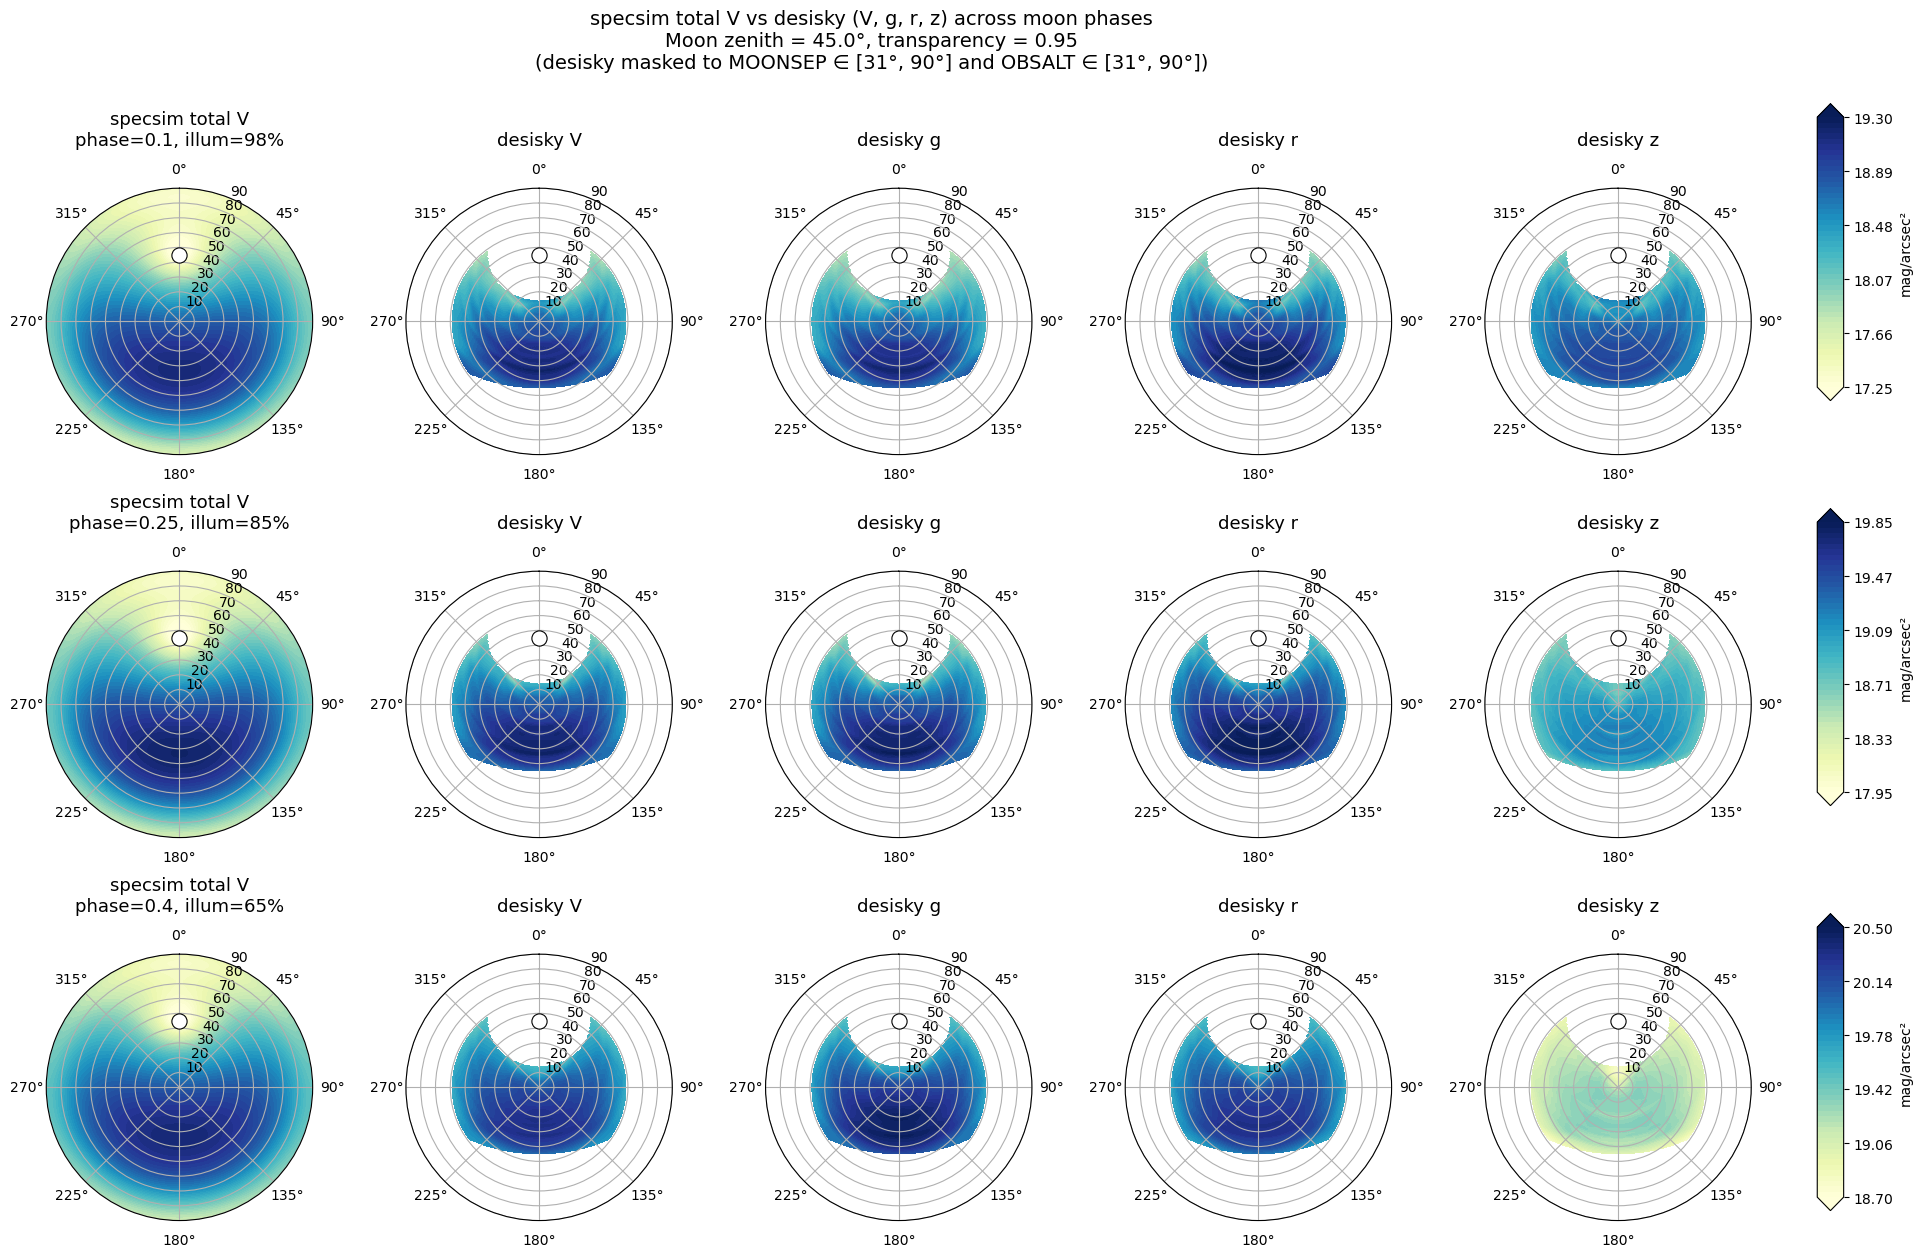

In [14]:
# All three phases give MOONFRAC safely inside the training filter (> 0.5):
#   phase=0.1  -> illum=0.975
#   phase=0.25 -> illum=0.854
#   phase=0.4  -> illum=0.655
moon_phases_ks = [0.1, 0.25, 0.4]

fig = plt.figure(figsize=(22, len(moon_phases_ks) * 4.5))
gs = fig.add_gridspec(len(moon_phases_ks), 5, hspace=0.4, wspace=0.35)

for row, phase in enumerate(moon_phases_ks):
    illum = 0.5 * (1 + np.cos(np.pi * phase))

    # --- specsim total V (KS91 moonlight + airmass-extincted dark floor) ---
    ks_moon = krisciunas_schaefer(
        obs_zenith_2d * u.deg, moon_zenith_deg * u.deg,
        sep_deg * u.deg, phase, vband_extinction,
    ).value
    flux_moon_row = 10.0 ** (-0.4 * ks_moon)
    flux_dark_row = 10.0 ** (-0.4 * dark_V_pointing)
    spec_total_row = -2.5 * np.log10(flux_moon_row + flux_dark_row)

    # --- desisky (V, g, r, z) ---
    inp = np.column_stack([
        sep_deg.ravel(),
        obs_alt_2d.ravel(),
        np.full(n_points, moon_alt_deg),
        np.full(n_points, illum),
        np.full(n_points, transparency_gfa),
        np.full(n_points, eclipse_frac),
    ]).astype(np.float32)
    p = np.array(jax.vmap(model)(jnp.array(inp)))
    ds_bands = {name: p[:, i].reshape(obs_zenith_2d.shape) for i, name in enumerate(band_names)}

    # Color range for this row (desisky uses valid region only). Computed from
    # the joint percentile window of all 5 panels so they share one bar, then
    # rounded to 0.05-mag steps for clean tick labels.
    spec_finite = spec_total_row[np.isfinite(spec_total_row)]
    vmin_r = np.percentile(spec_finite, 1)
    vmax_r = np.percentile(spec_finite, 99)
    for b in band_names:
        bv = ds_bands[b][valid_mask]
        vmin_r = min(vmin_r, np.percentile(bv, 1))
        vmax_r = max(vmax_r, np.percentile(bv, 99))
    vmin_r, vmax_r = _round_vrange(vmin_r, vmax_r)

    # specsim panel (full sky, no mask)
    ax0 = fig.add_subplot(gs[row, 0], projection='polar')
    cax_row = make_polar_ax(ax0, spec_total_row,
                            f'specsim total V\nphase={phase}, illum={illum:.0%}',
                            'YlGnBu', vmin_r, vmax_r, moon_az_rad, moon_zenith_deg)

    # desisky panels (masked to valid region)
    for col, band in enumerate(band_names):
        ax = fig.add_subplot(gs[row, col + 1], projection='polar')
        cax_row = make_polar_ax(ax, ds_bands[band], f'desisky {band}',
                                'YlGnBu', vmin_r, vmax_r, moon_az_rad, moon_zenith_deg,
                                mask=valid_mask)

    # Colorbar for this row, with rounded tick labels
    cbar_ax = fig.add_axes([0.93, 0.72 - row * 0.3, 0.012, 0.22])
    cb_row = fig.colorbar(cax_row, cax=cbar_ax, label='mag/arcsec²')
    cb_row.set_ticks(np.round(np.linspace(vmin_r, vmax_r, 6), 2))

fig.suptitle(
    f'specsim total V vs desisky (V, g, r, z) across moon phases\n'
    f'Moon zenith = {moon_zenith_deg}°, transparency = {transparency_gfa}\n'
    f'(desisky masked to MOONSEP ∈ [31°, 90°] and OBSALT ∈ [31°, 90°])',
    fontsize=14, y=1.01,
)

plt.savefig('polar_multi_phase.png', dpi=200, bbox_inches='tight')
plt.show()

## Notes

**For the presentation (slide 3):**
- Use the figure from section 5 as the main comparison visual
- The specsim panel is now **total sky brightness** (KS91 moonlight +
  airmass-extincted dark floor), not just scattered moonlight — this makes
  the V-band comparison apples-to-apples with desisky
- Section 6 shows the V-band side-by-side + residual (the apples-to-apples story)
- The g, r, z desisky panels are shown for extended capability — specsim
  has no direct equivalent (KS91 is V-band only; specsim's grey-reflector
  assumption gives the same spatial pattern in all bands scaled by a constant)

**How the specsim total V is computed (apples-to-apples):**
1. KS91 gives V-band scattered moonlight (already airmass-aware via
   `obs_zenith` in its formula)
2. Dark-sky V-band floor ≈ 21.63 mag/arcsec² computed from the median of
   ~1000 near-zenith dark-time DESI spectra via the `bessell-V` filter
   (self-consistent with desisky's training data)
3. Dark floor is airmass-extincted across the grid:
   `dark_V(X) = dark_V_zenith + ext * (X - 1)` where X = airmass and
   ext = 0.162 (matches specsim's `extinct_emission=True`)
4. Moonlight + dark floor are added in **flux space**, not magnitude space:
   `total_V = -2.5 * log10(10^(-0.4*moon) + 10^(-0.4*dark))`

**Why desisky is masked to MOONSEP ∈ [31°, 90°] and OBSALT ∈ [31°, 90°]:**
- The broadband model's training data has MOONSEP ∈ [31.5°, 90°] and
  OBSALT ∈ [30.9°, 89.8°]. We mask **both** lower and upper bounds because
  ReLU MLPs extrapolate badly in either direction.
- An earlier version of this notebook only masked MOONSEP > 90°, which
  left the MOONSEP < 31° region (right around the moon) as extrapolation.
  This caused visible ringing in V/g/r and a bogus "dark ring" in z-band
  near the moon — those were extrapolation artifacts, not physics.
- The tighter mask corresponds to DESI's actual moon-contaminated observing
  envelope. A full specsim integration would dispatch to `ldm_dark` for
  MOONSEP > 90° and to `ldm_twilight` for sun-up regimes. The broadband
  model is just the moon-up variant.

**Interpreting the V-band residual plot (section 6):**
- **Within the valid region**, residuals should be small (typically <0.2 mag)
  with structured variation that represents real differences between
  specsim's approximations and what the data shows.
- **Positive residual** (desisky mag > specsim mag): desisky predicts
  the sky is *fainter* than specsim at that pixel. Could happen if specsim
  over-estimates moonlight scattering or underestimates extinction.
- **Negative residual** (desisky mag < specsim mag): desisky predicts the
  sky is *brighter* than specsim. Likely places for this: zodiacal light
  near the ecliptic, airglow enhancements, galactic-latitude continuum —
  all things specsim's static dark template doesn't capture.
- **If you see residuals > ±0.5 mag or obvious ringing, that's almost
  always extrapolation leaking through the mask** — double check the
  training envelope.

**Caveats:**
- specsim's `extinct_emission` treatment is a simplification (it ignores
  that the airglow path length also increases with airmass, which partially
  cancels the extinction). We use it here because it's specsim's own
  convention — so the baseline is internally consistent with specsim.
- The dark V-band floor is computed from DESI dark-time spectra with
  OBSALT > 70° (airmass ≤ ~1.06), treated as the "zenith" reference. The
  ≤0.01 mag bias from this approximation is negligible for a presentation
  figure.
- z-band is noisy even within the valid region because DESI z-band sky
  brightness is dominated by OH airglow, which has strong night-to-night
  variability and isn't a smooth function of moon geometry. The MLP learned
  this from data, so expect more scatter in z than in V/g/r.